In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from ExtremeLearningMachine import ExtremeLearningMachine

In [26]:
filePath = '../../Dataset/UCI_Gallstone_Dataset.csv'
hiddenSize = 25
RANDOM_STATE = 47

df = pd.read_csv(filePath)
# Separate Features and Target
targetCol = ['Gallstone Status']
X = df.drop(targetCol, axis=1)
y = df[targetCol]

In [27]:
def benchmark_elm_performance(df, target_col, hidden_sizes, random_state=42):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    y_train_vals = y_train_full.values.ravel()
    results_summary = []

    for h_size in hidden_sizes:
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

        # Dictionary to store all 10-fold results for distribution analysis
        cv_metrics = {
            'acc': [], 'prec': [], 'rec': [], 'spec': [], 'f1': []
        }

        for train_idx, val_idx in skf.split(X_train_full, y_train_vals):
            X_tf, X_vf = X_train_full.values[train_idx], X_train_full.values[val_idx]
            y_tf, y_vf = y_train_vals[train_idx], y_train_vals[val_idx]

            scaler = MinMaxScaler()
            X_tf_scaled = scaler.fit_transform(X_tf)
            X_vf_scaled = scaler.transform(X_vf)

            model = ExtremeLearningMachine(input_size=X_tf.shape[1], hidden_size=h_size)
            model.initialize_random_weights(random_seed=random_state)
            model.fit(X_tf_scaled, y_tf)

            # Trigger metrics calculation for the current fold
            model.set_evaluation_metrics(X_vf_scaled, y_vf)
            m_fold = model.get_evaluation_metrics()

            cv_metrics['acc'].append(m_fold[0])
            cv_metrics['prec'].append(m_fold[1])
            cv_metrics['rec'].append(m_fold[2])
            cv_metrics['spec'].append(m_fold[3])
            cv_metrics['f1'].append(m_fold[4])

        # --- FINAL TEST ON UNSEEN DATA ---
        final_scaler = MinMaxScaler()
        X_train_final = final_scaler.fit_transform(X_train_full)
        X_test_final = final_scaler.transform(X_test)

        final_model = ExtremeLearningMachine(input_size=X_train_full.shape[1], hidden_size=h_size)
        final_model.initialize_random_weights(random_seed=random_state)
        final_model.fit(X_train_final, y_train_vals)
        final_model.set_evaluation_metrics(X_test_final, y_test.values.ravel())
        m_test = final_model.get_evaluation_metrics()

        # Build the result row with Min, Max, and Avg for CV metrics
        row = {'hidden_nodes': h_size}

        for name, values in cv_metrics.items():
            row[f'cv_{name}_avg'] = np.mean(values)
            row[f'cv_{name}_min'] = np.min(values)
            row[f'cv_{name}_max'] = np.max(values)
            row[f'cv_{name}_std'] = np.std(values) # Added standard deviation

        # Add final test results
        row.update({
            'test_acc': m_test[0], 'test_prec': m_test[1],
            'test_rec': m_test[2], 'test_spec': m_test[3], 'test_f1': m_test[4]
        })

        results_summary.append(row)

    return pd.DataFrame(results_summary)

In [28]:
datasets_config = {
    "Gallstone": {"path": "../../Dataset/UCI_Gallstone_Dataset.csv", "target": "Gallstone Status"},
    "Dataset":   {"path": "../../Dataset/Dataset.csv", "target": "Gallstone Status"} # Assuming same target name
}

node_configs = list(range(1, 81, 1))
all_reports = {}

for name, config in datasets_config.items():
    try:
        data = pd.read_csv(config["path"])
        report = benchmark_elm_performance(data, config["target"], node_configs)
        all_reports[name] = report
    except FileNotFoundError:
        print(f"Error: File not found at {config['path']}")
    except Exception as e:
        print(f"An error occurred with {name}: {e}")


gallstone_report = all_reports.get("Gallstone")
dataset_report = all_reports.get("Dataset")

In [29]:
def plot_elm_robustness(report_df, dataset_name):
    sns.set_theme(style="whitegrid")

    metrics = [
        ('acc', 'Accuracy'),
        ('prec', 'Precision'),
        ('rec', 'Recall'),
        ('spec', 'Specificity'),
        ('f1', 'F1-Score')
    ]

    for key, name in metrics:
        plt.figure(figsize=(12, 7))

        nodes = report_df['hidden_nodes']
        avg = report_df[f'cv_{key}_avg']
        ymin = report_df[f'cv_{key}_min']
        ymax = report_df[f'cv_{key}_max']
        std = report_df[f'cv_{key}_std']
        test = report_df[f'test_{key}']

        # 1. Plot Min, Avg, Max Lines
        plt.plot(nodes, avg, color='blue', linewidth=0.8, label=f'Avg {name}', marker='o')
        plt.plot(nodes, ymin, color='skyblue', linestyle='--', linewidth=0.5, label=f'Min {name}')
        plt.plot(nodes, ymax, color='navy', linestyle='--', linewidth=0.5, label=f'Max {name}')

        # 2. Add Shaded Area for Standard Deviation
        plt.fill_between(nodes, avg - std, avg + std, color='blue', alpha=0.15, label='Std Dev Range')

        # 3. Plot the Final Holdout Test result
        plt.plot(nodes, test, color='red', linewidth=0.8, label=f'Final Test {name}', marker='s')

        # Formatting
        plt.title(f'{dataset_name}: {name} Analysis', fontsize=15, pad=15)
        plt.xlabel('Number of Hidden Nodes', fontsize=12)
        plt.ylabel(f'{name} Score', fontsize=12)
        plt.legend(loc='lower right', frameon=True, shadow=True)
        plt.ylim(-0.05, 1.05) # Keep scale consistent for 0-1 metrics
        plt.grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        plt.show()


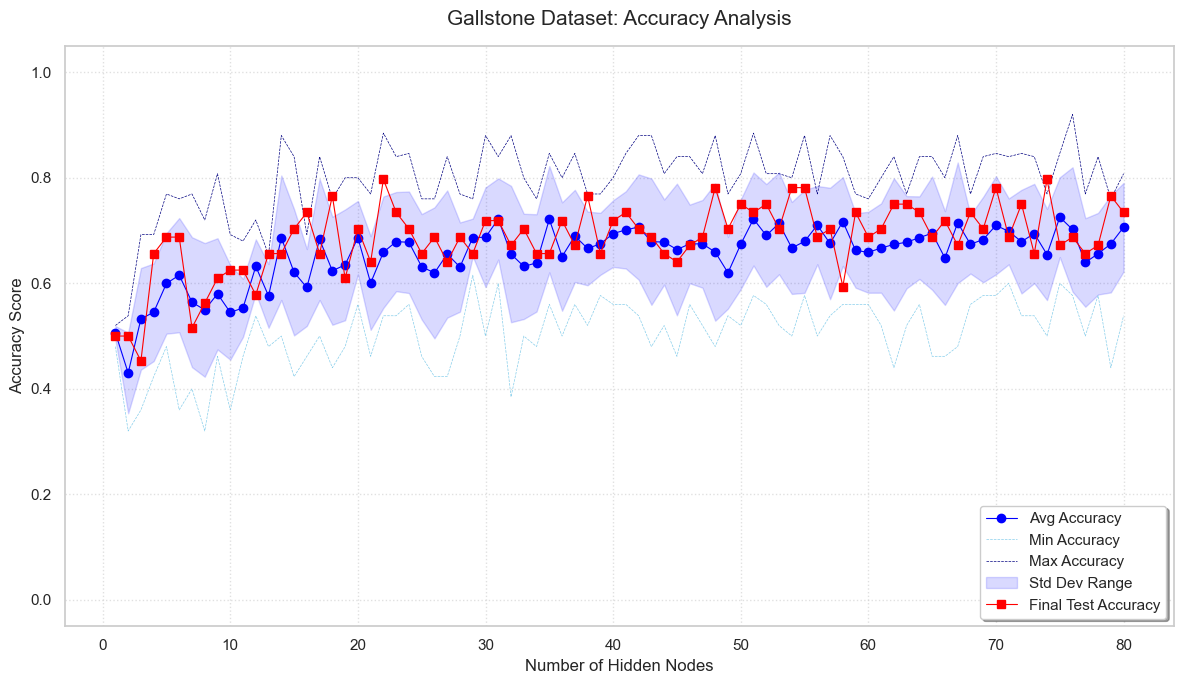

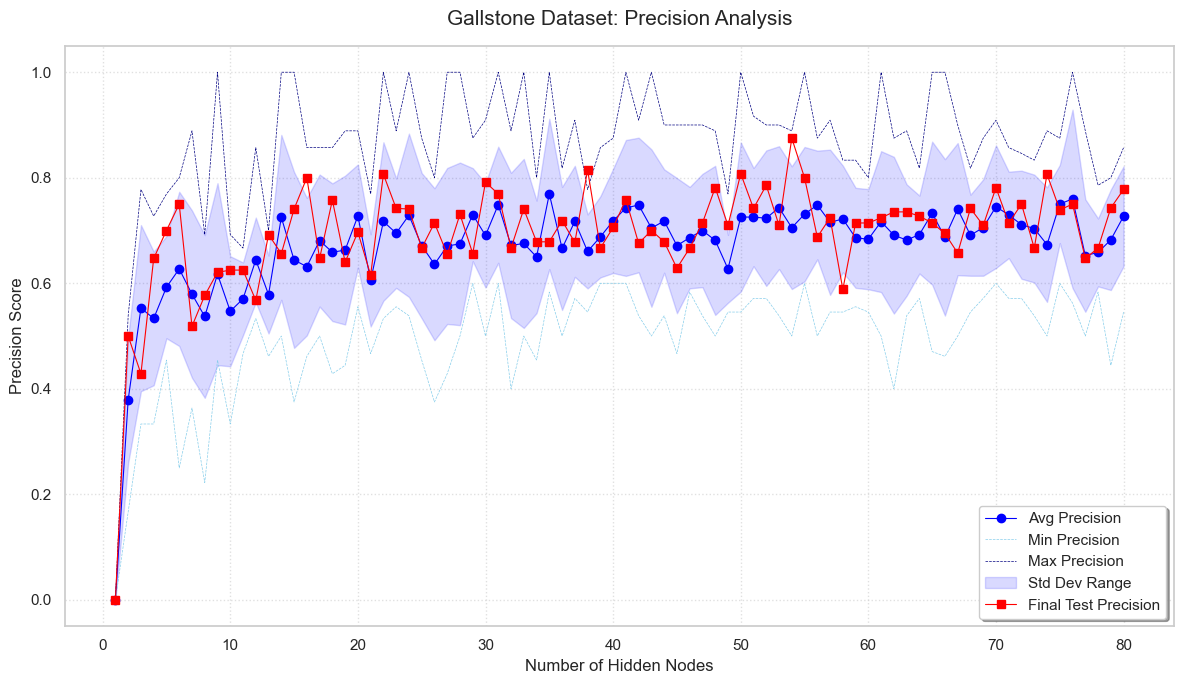

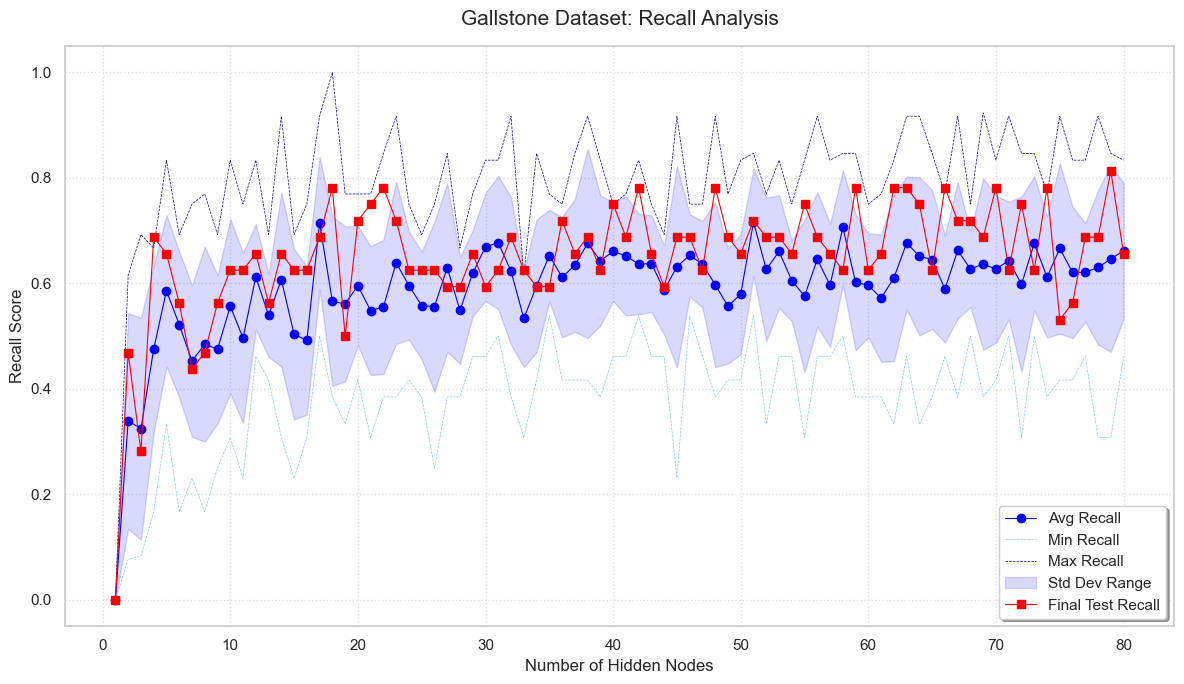

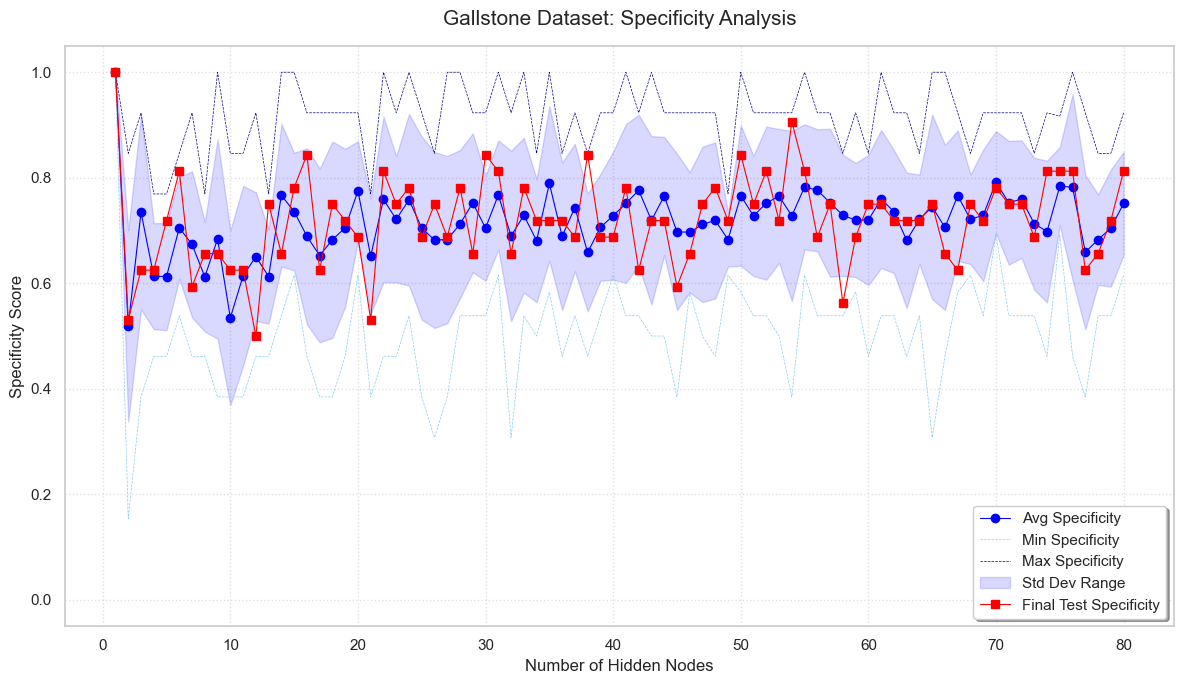

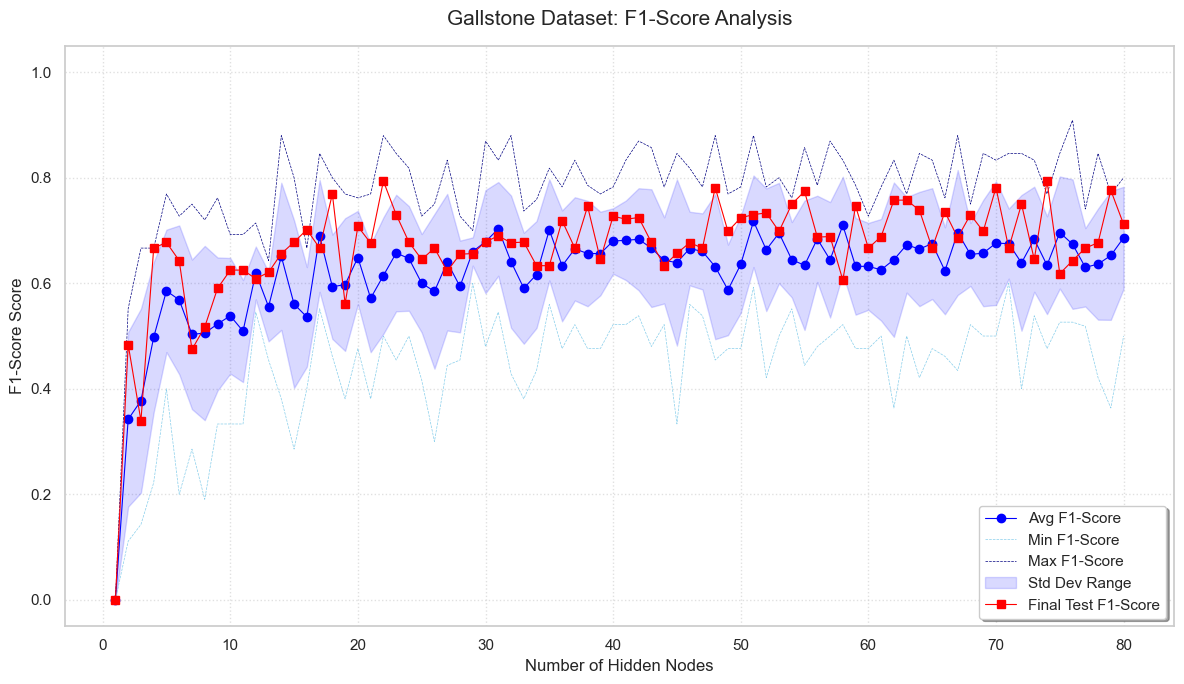

In [30]:
plot_elm_robustness(gallstone_report, "Gallstone Dataset")

In [31]:
# Ensure both reports exist before calculating
if gallstone_report is not None and dataset_report is not None:
    # We only care about columns starting with 'test_' and the 'hidden_nodes'
    test_cols = [col for col in gallstone_report.columns if col.startswith('test_')]

    # Calculate difference: (Gallstone - Dataset)
    diff_report = pd.DataFrame()
    diff_report['hidden_nodes'] = gallstone_report['hidden_nodes']

    for col in test_cols:
        diff_report[col] = gallstone_report[col] - dataset_report[col]
else:
    print("Error: One or both reports are missing. Check your file paths.")

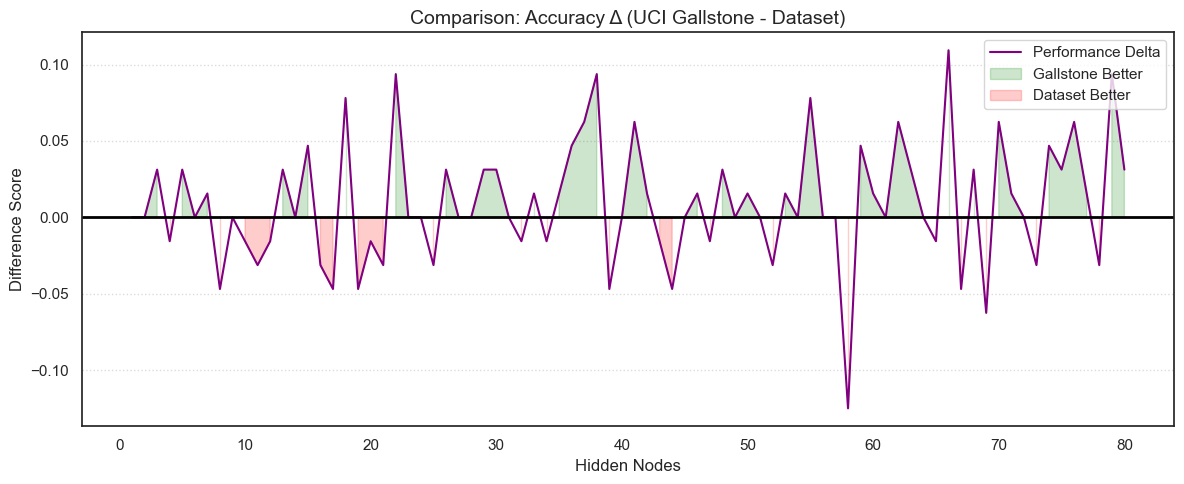

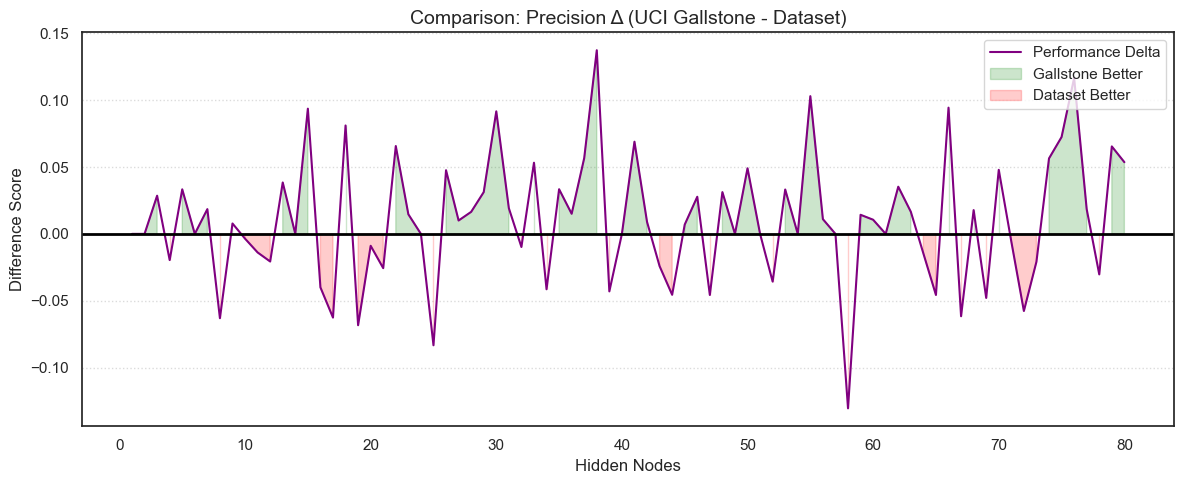

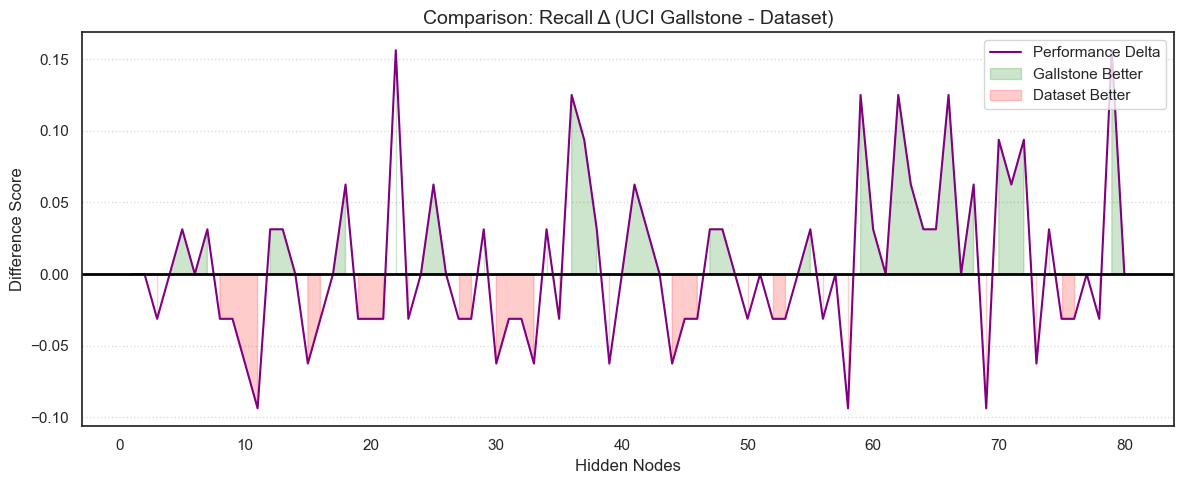

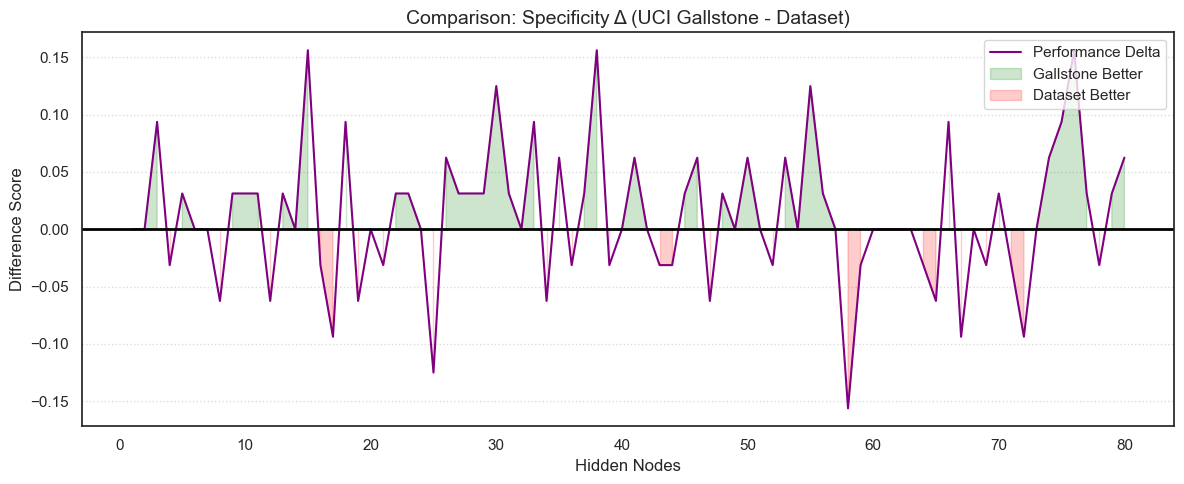

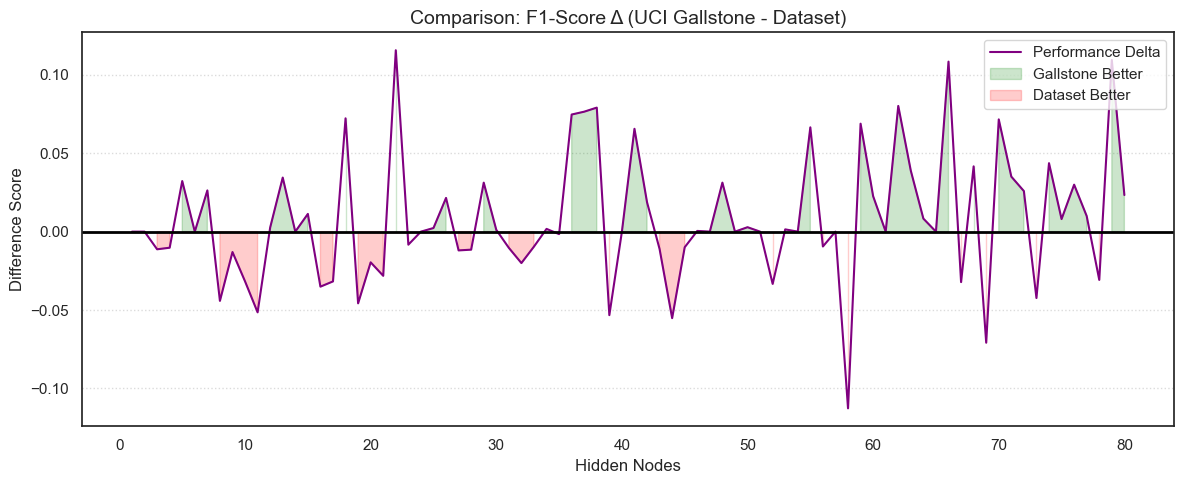

In [32]:
def plot_test_differences(diff_df):
    sns.set_theme(style="white")
    metrics = [
        ('test_acc', 'Accuracy Δ'),
        ('test_prec', 'Precision Δ'),
        ('test_rec', 'Recall Δ'),
        ('test_spec', 'Specificity Δ'),
        ('test_f1', 'F1-Score Δ')
    ]

    for key, name in metrics:
        plt.figure(figsize=(12, 5))

        # Plot the difference line
        plt.plot(diff_df['hidden_nodes'], diff_df[key], color='purple', linewidth=1.5, label='Performance Delta')

        # Fill area above/below zero for visual clarity
        plt.fill_between(diff_df['hidden_nodes'], diff_df[key], 0,
                         where=(diff_df[key] >= 0), color='green', alpha=0.2, label='Gallstone Better')
        plt.fill_between(diff_df['hidden_nodes'], diff_df[key], 0,
                         where=(diff_df[key] < 0), color='red', alpha=0.2, label='Dataset Better')

        # The Baseline
        plt.axhline(0, color='black', linestyle='-', linewidth=2)

        plt.title(f'Comparison: {name} (UCI Gallstone - Dataset)', fontsize=14)
        plt.xlabel('Hidden Nodes')
        plt.ylabel('Difference Score')
        plt.legend(loc='upper right')
        plt.grid(True, axis='y', linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()

# Run the plot
if 'diff_report' in locals():
    plot_test_differences(diff_report)